### Sturm-Liouville Eigenvalue Problem: Optimized Shooting Method Solution

The Sturm-Liouville eigenvalue problem is, in 1D:

$$
    f''(x) + \left[ k - V(x) \right] f(x) = 0
$$

With boundary conditions:

$$
    f(0) = f(L) = 0
$$

And $f(x)$ must be normalized for $x \in [0, L]$:

$$
    \int _{0} ^ {L} \left| f(x) \right| ^ 2 \, dx = 1
$$

The shooting method transforms this boundary value problem into an initial value problem:
1. Fix $f(x = 0) = 0$ and choose $f'(x = 0) = 1$ (the magnitude doesn't matter due to linearity)
2. Solve the ODE for different trial eigenvalues $k$
3. Find $k$ values where $f(L) = 0$ (satisfying the right boundary condition)
4. These $k$ values are the eigenvalues, and their corresponding solutions are eigenfunctions

In [1]:
import numpy as np

from scipy.integrate import solve_ivp # Solves ODEs
from scipy.optimize import brentq # Finds the roots of a function

import matplotlib.pyplot as plt
plt.style.use("ggplot") # Plotting style

In [2]:
def ode(x, y, k):
    global V
    
    dSdx = np.zeros(2)
    dSdx[0] = y[1]  # f' = df/dx
    dSdx[1] = (V(x) - k) * y[0]  # f'' = (V - k)f
    
    return dSdx

def solve_for_k(k_value, last_element = True):
    global L
    
    y0 = [0.0, 1.0] # Initial conditions: f(0) = 0, f'(0) = 1
    
    sol = solve_ivp( # Solve the ODE
        fun = lambda x, y: ode(x, y, k_value),
        t_span = [0, L],
        y0 = y0,
        dense_output = True # Better for root finding
    )
    
    if last_element:
        return sol.y[0, - 1] # Return f(L)
    else:

        # Return the full solution normalized
        x = np.linspace(0, L, 100)
        y = sol.sol(x)[0]
        
        # Normalize
        norm = np.sqrt(np.trapezoid(y ** 2, x))
        y = y / norm
        
        return x, y

def shooting_method(k_min, k_max, n_points, monitor = 100):
    global L
    
    k_values = np.linspace(k_min, k_max, n_points)
    f_values = np.zeros_like(k_values)
    
    print("Scanning k values...")
    
    # First pass: compute f(L) for each k
    for i, k in enumerate(k_values):
        f_values[i] = solve_for_k(k)
        
        if i % monitor == 0:
            print(f"k = {k:.2f}, f(L) = {f_values[i]:.4e}")
    
    # Find intervals where f(L) changes sign (potential eigenvalues)
    roots = []
    for i in range(len(k_values) - 1):
        if f_values[i] * f_values[i + 1] < 0:
            # Found sign change, use brentq to find root
            try:
                # Define a wrapper function for brentq
                def f_at_L(k_val):
                    return solve_for_k(k_val)
                
                # Find exact root in this interval
                root = brentq(f_at_L, k_values[i], k_values[i + 1])
                roots.append(root)
                print(f"Found eigenvalue: k = {root:.6f}")
            except Exception as e:
                print(f"Error finding root in interval [{k_values[i]}, {k_values[i+1]}]: {e}")
    
    return roots

def plot_eigs(roots):
    plt.figure(figsize = (10, 5))
    
    for _, r in enumerate(roots):
        x, y = solve_for_k(r, last_element = False)
        plt.plot(x, y, label = f'k = {r:.6f}', linewidth = 1.5)
    
    plt.title(f"First {len(roots)} Eigenfunction(s)")
    plt.legend(bbox_to_anchor = (1, 1))
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.grid(True, alpha = 0.5)
    plt.tight_layout()
    plt.show()

Scanning k values...
k = -50.00, f(L) = 8.8741e+04
k = -34.98, f(L) = 1.0335e+04
k = -19.97, f(L) = 7.3625e+02
k = -4.95, f(L) = 1.5089e+01
k = 10.06, f(L) = 8.3751e-02
k = 25.08, f(L) = -1.3133e-01
k = 40.09, f(L) = 3.4280e-02
k = 55.11, f(L) = 9.0635e-02
k = 70.12, f(L) = -1.0716e-01
k = 85.14, f(L) = -3.2220e-02
Found eigenvalue: k = 1.906619
Found eigenvalue: k = 9.134679
Found eigenvalue: k = 21.427685
Found eigenvalue: k = 38.675528
Found eigenvalue: k = 60.862495
Found eigenvalue: k = 87.984386


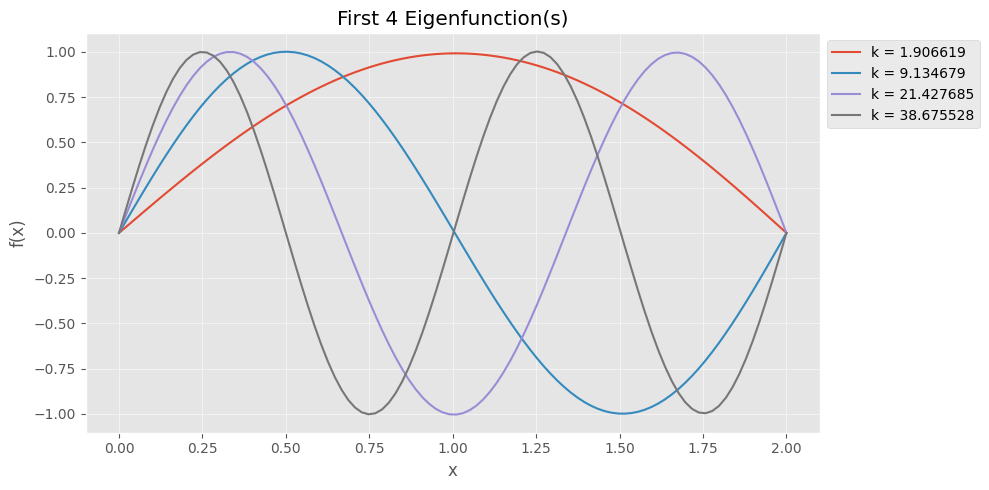

In [3]:
# Globals
L = 2
V = lambda x: - x ** 4 / 4 + x ** 3 / 3 - x ** 2 / 2 + x - 1 # Can be anything

r = shooting_method(
    k_min = - 50,
    k_max = 100,
    n_points = 1_000
)

plot_eigs(r[0:4])

Scanning k values...
k = -100.00, f(L) = 8.3237e+01
k = -89.99, f(L) = 4.4089e+01
k = -79.98, f(L) = 2.1799e+01
k = -69.97, f(L) = 9.7608e+00
k = -59.96, f(L) = 3.7126e+00
k = -49.95, f(L) = 9.9168e-01
k = -39.94, f(L) = -9.7118e-03
k = -29.93, f(L) = -2.1726e-01
k = -19.92, f(L) = -1.3043e-01
k = -9.91, f(L) = 7.9034e-03
Found eigenvalue: k = -40.134414
Found eigenvalue: k = -10.540937


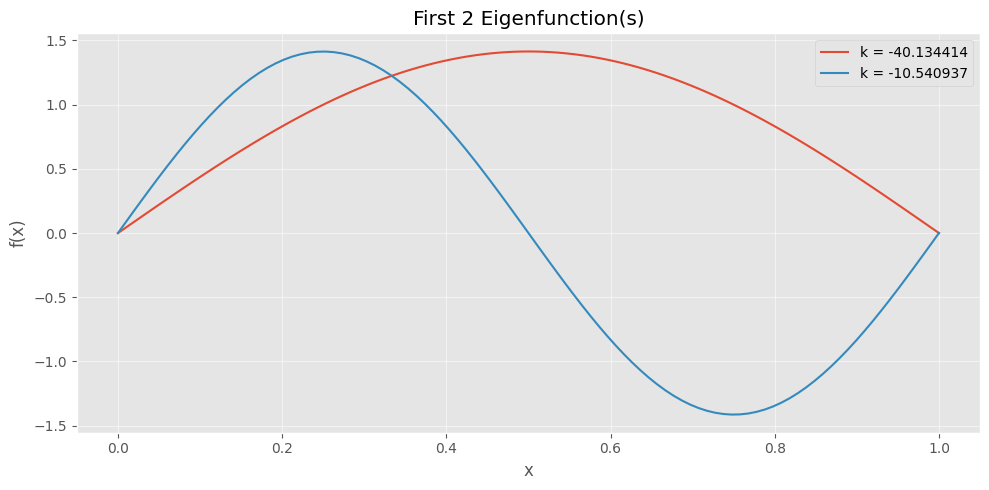

In [4]:
L = 1
V = lambda _: - 50 # Constant potential

r = shooting_method(
    k_min = - 100,
    k_max = 0, # Searching only negative eigenvalues
    n_points = 1_000
)

plot_eigs(r)